# 🥥 Costos de producción y punto de equilibrio · Cocoil

**Proyecto:** coco-analytics · **Notebook 02** · julio 2026

Modela cuánto cuesta producir aceite de coco virgen en Bolivia y cuántas unidades
hay que vender al mes para no perder plata, usando los **datos reales** de los
notebooks anteriores:

- **Precio de la competencia:** 21 productos relevados (`datos/competencia_listings_bolivia.csv`) — mediana **Bs 29/100 ml**.
- **Costo del aceite importado:** CIF **US$ 2,6–5/kg** (microdato INE, `datos/ine_aceite_coco_anual.csv`).

> ⚠️ **Qué es dato y qué es supuesto.** Los precios de competencia y el CIF son **datos**.
> Los costos de producción (precio del coco, rendimiento, envases, mano de obra, fijos)
> son **SUPUESTOS razonables a validar en campo** — están todos en una sola celda
> (§2) para que los edites con tus números reales y re-ejecutes. El resultado del
> notebook cambia solo, incluidos los gráficos.


## 1. Preparación

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BASE = Path.cwd()
ANALISIS = BASE if (BASE / "datos").exists() else BASE / "analisis"
DATOS = ANALISIS / "datos"
sys.path.append(str(ANALISIS.parent / "src"))
from estilo import aplicar_estilo, guardar, COCO, PALETA
aplicar_estilo()

listings = pd.read_csv(DATOS / "competencia_listings_bolivia.csv")
ine = pd.read_csv(DATOS / "ine_aceite_coco_anual.csv")
print("Datos cargados:", len(listings), "productos de competencia ·", len(ine), "años de serie INE")


Datos cargados: 21 productos de competencia · 12 años de serie INE


## 2. ⚙️ Supuestos — EDITÁ ESTA CELDA con tus números reales

Cada parámetro tiene su justificación al lado. Cuando tengas cotizaciones reales
(coco puesto en planta, frascos, rendimiento de **tu** prensa), reemplazá y re-ejecutá todo.

In [2]:
P = {
    # --- Materia prima (A VALIDAR en Santa Cruz/Chapare) ---
    "precio_coco_bs": 6.0,        # Bs por coco seco puesto en planta (rango típico 4-10)
    "rendimiento_ml_coco": 120,   # ml de aceite virgen por coco (prensado en frío: 80-180 según prensa y pulpa)
    "merma_pct": 10,              # % de pérdida de proceso

    # --- Envase y presentación (cotizar en vidrierías/importadores locales) ---
    "frasco_200_bs": 4.5,         # frasco vidrio 200 ml + tapa
    "frasco_400_bs": 6.5,
    "frasco_720_bs": 9.0,
    "etiqueta_bs": 1.0,           # etiqueta impresa por unidad

    # --- Proceso ---
    "mano_obra_bs_litro": 12.0,   # Bs de mano de obra por litro producido
    "energia_insumos_bs_litro": 3.0,  # gas/energía/limpieza por litro

    # --- Costos fijos mensuales ---
    "alquiler_bs_mes": 2500,      # taller pequeño
    "sueldos_fijos_bs_mes": 3500, # medio tiempo propio/socio prorrateado
    "otros_fijos_bs_mes": 500,    # transporte, comunicación, varios
    "prensa_usd": 2500,           # inversión en prensa (la que ya estás comprando)
    "amortizacion_meses": 36,     # meses para amortizar la prensa
    "senasag_bs_2anios": 500,     # registro artesanal (dato SENASAG, notebook 01)

    # --- Precio y mercado ---
    "tc_bs_usd": 6.96,            # tipo de cambio oficial
    "precio_venta_200_bs": 55.0,  # tu precio objetivo por 200 ml (BeCoco vende 200 ml a Bs 49-55)
    "cif_importado_usd_kg": 3.0,  # costo CIF del aceite importado a granel (INE: $2,6-5/kg)
    "arancel_ga_pct": 10,         # GA importación (confirmar en AAI-2026)
    "iva_import_pct": 14.94,      # IVA efectivo de importación
    "densidad_kg_l": 0.92,        # densidad del aceite de coco
}

fijos_mes = (P["alquiler_bs_mes"] + P["sueldos_fijos_bs_mes"] + P["otros_fijos_bs_mes"]
             + P["prensa_usd"] * P["tc_bs_usd"] / P["amortizacion_meses"]
             + P["senasag_bs_2anios"] / 24)
print(f"Costos fijos mensuales: Bs {fijos_mes:,.0f}")


Costos fijos mensuales: Bs 7,004


## 3. Costo variable por presentación

Cuánto cuesta poner un frasco en la mesa (sin fijos): coco + envase + etiqueta + mano de obra + energía, con la merma incluida.

,200 ml,400 ml,720 ml
Coco (materia prima),11.11,22.22,40.00
Frasco + tapa,4.50,6.50,9.00
Etiqueta,1.00,1.00,1.00
Mano de obra,2.40,4.80,8.64
Energía e insumos,0.60,1.20,2.16
TOTAL,19.61,35.72,60.80


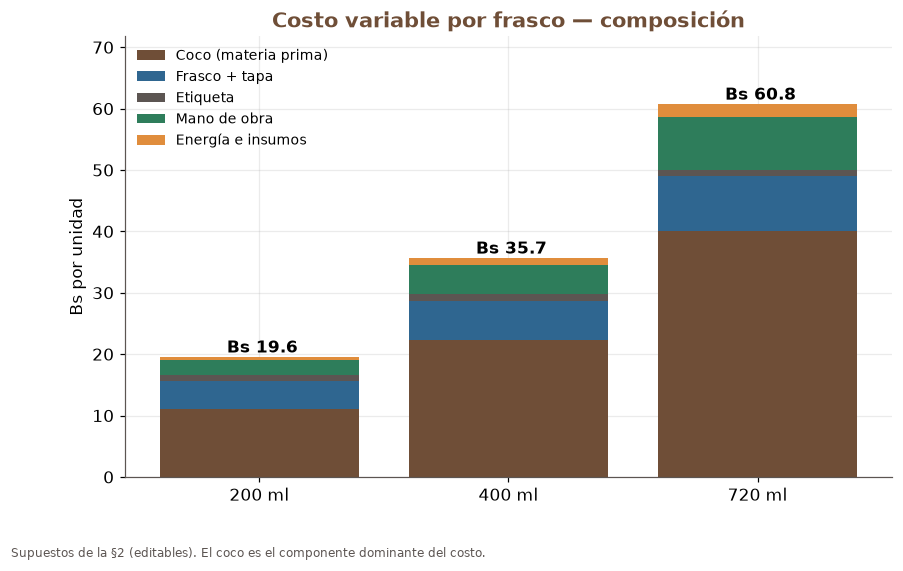

Frasco 200 ml: costo variable Bs 19.6 · precio Bs 55 · margen bruto Bs 35.4 (64%)


In [3]:
def costo_variable(ml, frasco_bs):
    litros = ml / 1000
    cocos = (ml / P["rendimiento_ml_coco"]) / (1 - P["merma_pct"] / 100)
    return {
        "Coco (materia prima)": cocos * P["precio_coco_bs"],
        "Frasco + tapa": frasco_bs,
        "Etiqueta": P["etiqueta_bs"],
        "Mano de obra": litros * P["mano_obra_bs_litro"],
        "Energía e insumos": litros * P["energia_insumos_bs_litro"],
    }

presentaciones = {200: P["frasco_200_bs"], 400: P["frasco_400_bs"], 720: P["frasco_720_bs"]}
comp = pd.DataFrame({f"{ml} ml": costo_variable(ml, fr) for ml, fr in presentaciones.items()})
comp.loc["TOTAL"] = comp.sum()
display(comp.round(2))

fig, ax = plt.subplots(figsize=(9, 5.2))
colores = [COCO["marron"], COCO["azul"], COCO["gris"], COCO["verde"], COCO["acento"]]
abajo = np.zeros(len(presentaciones))
etiquetas = [f"{ml} ml" for ml in presentaciones]
for i, fila in enumerate(comp.index[:-1]):
    vals = comp.loc[fila].values
    ax.bar(etiquetas, vals, bottom=abajo, label=fila, color=colores[i])
    abajo += vals
for x, t in zip(etiquetas, comp.loc["TOTAL"]):
    ax.text(x, t, f" Bs {t:,.1f}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Costo variable por frasco — composición")
ax.set_ylabel("Bs por unidad")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0, comp.loc["TOTAL"].max() * 1.18)
plt.figtext(0.01, -0.03, "Supuestos de la §2 (editables). El coco es el componente dominante del costo.",
            fontsize=8, color=COCO["gris"])
guardar("09_costo_variable")
plt.show()

cv200 = comp.loc["TOTAL", "200 ml"]
margen200 = P["precio_venta_200_bs"] - cv200
print(f"Frasco 200 ml: costo variable Bs {cv200:.1f} · precio Bs {P['precio_venta_200_bs']:.0f}"
      f" · margen bruto Bs {margen200:.1f} ({margen200/P['precio_venta_200_bs']*100:.0f}%)")


## 4. ¿Dónde caés frente a la competencia?

Tu costo variable y tu precio objetivo por 100 ml, superpuestos al ranking real de la competencia (comestibles, jul-2026).

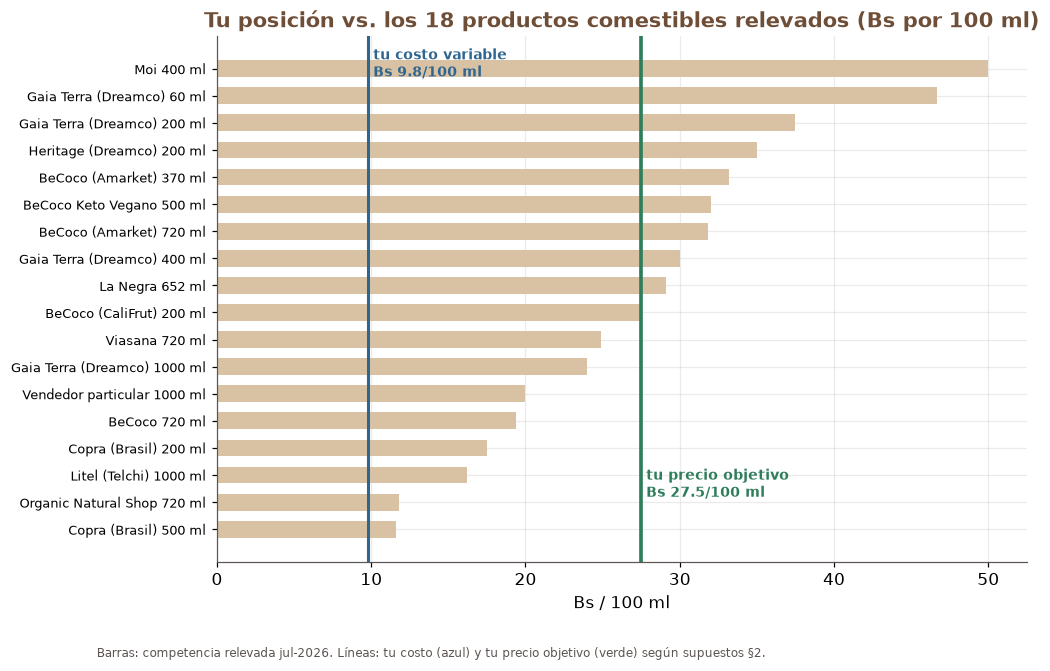

A Bs 55 el frasco de 200 ml (27.5/100 ml), 8 de 18 productos comestibles son más baratos que vos.


In [4]:
com = listings[~listings["tipo"].str.contains("cosmetico")].sort_values("bs_100ml")
tu_costo_100 = cv200 / 2
tu_precio_100 = P["precio_venta_200_bs"] / 2

fig, ax = plt.subplots(figsize=(9.5, 6.2))
y = np.arange(len(com))
ax.barh(y, com["bs_100ml"], color=COCO["arena"], height=0.62)
ax.set_yticks(y, [f'{m} {int(v)} ml' for m, v in zip(com["marca"], com["ml"])], fontsize=8.5)
ax.axvline(tu_costo_100, color=COCO["azul"], linewidth=2, linestyle="-")
ax.axvline(tu_precio_100, color=COCO["verde"], linewidth=2.4)
ax.text(tu_costo_100, len(com)-.2, f" tu costo variable\n Bs {tu_costo_100:.1f}/100 ml",
        color=COCO["azul"], fontsize=9, fontweight="bold", va="top")
ax.text(tu_precio_100, 1.2, f" tu precio objetivo\n Bs {tu_precio_100:.1f}/100 ml",
        color=COCO["verde"], fontsize=9, fontweight="bold")
ax.set_title("Tu posición vs. los 18 productos comestibles relevados (Bs por 100 ml)")
ax.set_xlabel("Bs / 100 ml")
plt.figtext(0.01, -0.03, "Barras: competencia relevada jul-2026. Líneas: tu costo (azul) y tu precio objetivo (verde) según supuestos §2.",
            fontsize=8, color=COCO["gris"])
guardar("10_posicion_competencia")
plt.show()

mas_baratos = (com["bs_100ml"] < tu_precio_100).sum()
print(f"A Bs {P['precio_venta_200_bs']:.0f} el frasco de 200 ml ({tu_precio_100:.1f}/100 ml), "
      f"{mas_baratos} de {len(com)} productos comestibles son más baratos que vos.")


## 5. Punto de equilibrio

Cuántos frascos de 200 ml hay que vender **al mes** para cubrir los costos fijos, según el precio de venta que elijas.

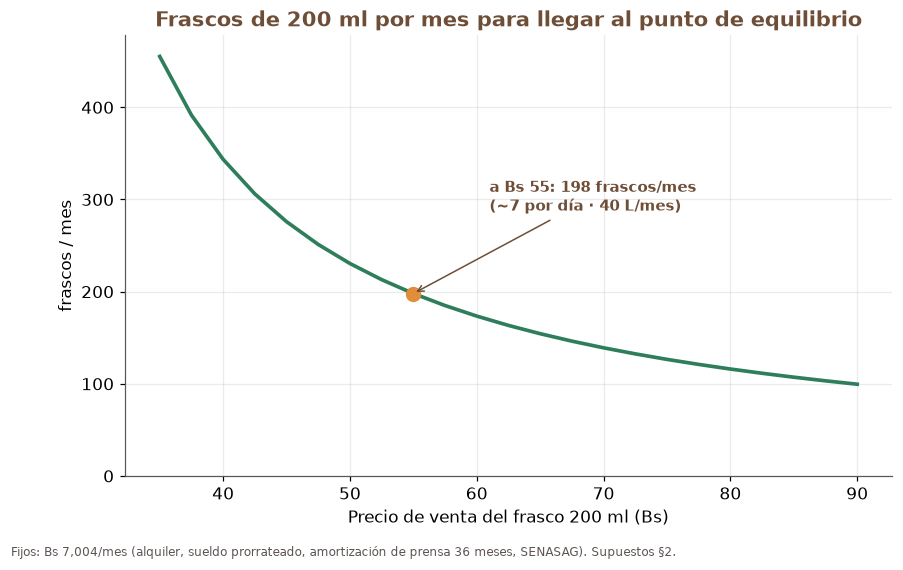

In [5]:
precios = np.arange(35, 91, 2.5)
unidades_eq = [fijos_mes / (p - cv200) if p > cv200 else np.nan for p in precios]

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(precios, unidades_eq, color=COCO["verde"], linewidth=2.4)
p0 = P["precio_venta_200_bs"]
u0 = fijos_mes / (p0 - cv200)
ax.plot([p0], [u0], marker="o", markersize=9, color=COCO["acento"])
ax.annotate(f"a Bs {p0:.0f}: {u0:,.0f} frascos/mes\n(~{u0/30:.0f} por día · {u0*0.2:,.0f} L/mes)",
            xy=(p0, u0), xytext=(p0+6, u0+90), fontsize=10, fontweight="bold", color=COCO["marron"],
            arrowprops={"arrowstyle": "->", "color": COCO["marron"]})
ax.set_title("Frascos de 200 ml por mes para llegar al punto de equilibrio")
ax.set_xlabel("Precio de venta del frasco 200 ml (Bs)")
ax.set_ylabel("frascos / mes")
ax.set_ylim(0, np.nanmax(unidades_eq) * 1.05)
plt.figtext(0.01, -0.03, f"Fijos: Bs {fijos_mes:,.0f}/mes (alquiler, sueldo prorrateado, amortización de prensa 36 meses, SENASAG). Supuestos §2.",
            fontsize=8, color=COCO["gris"])
guardar("11_punto_equilibrio")
plt.show()


## 6. Sensibilidad — las dos variables que más te importan

El **precio del coco** y el **rendimiento de tu prensa** dominan el resultado. Antes de escalar, medí ambos con precisión.

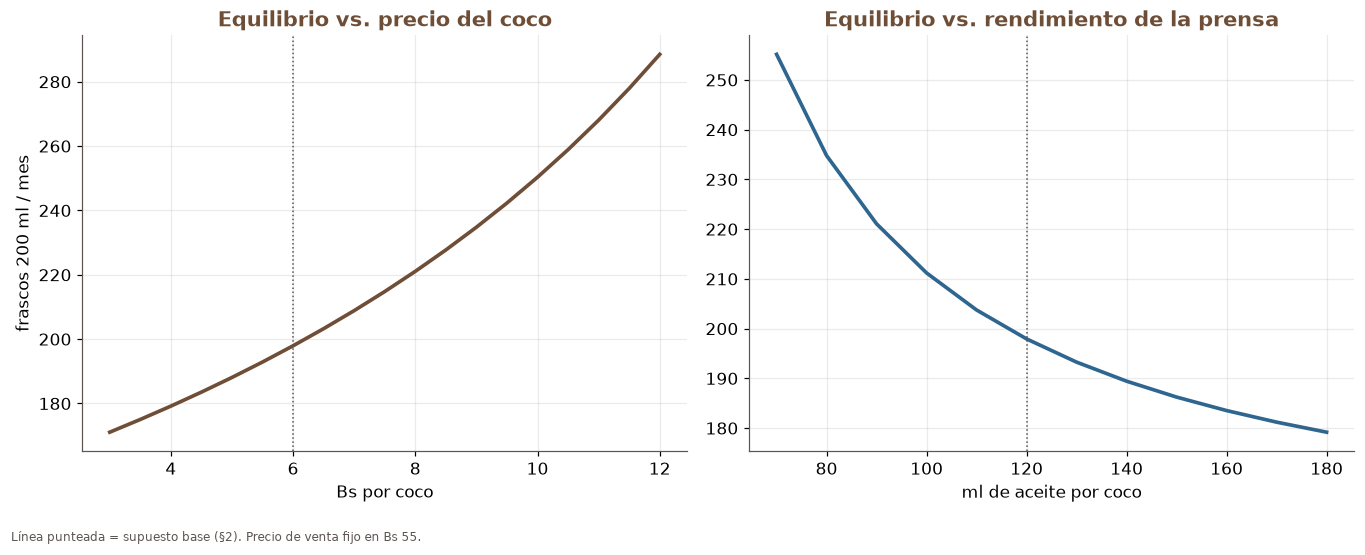

,Escenario,Coco Bs/u,Rendimiento ml/coco,Frascos/mes equilibrio,Litros/mes
0,Pesimista,9.0,90,289.0,58.0
1,Base,6.0,120,198.0,40.0
2,Optimista,4.0,150,176.0,35.0


In [6]:
def equilibrio(precio_coco=None, rendimiento=None):
    pc = precio_coco if precio_coco is not None else P["precio_coco_bs"]
    rn = rendimiento if rendimiento is not None else P["rendimiento_ml_coco"]
    cocos = (200 / rn) / (1 - P["merma_pct"] / 100)
    cv = (cocos * pc + P["frasco_200_bs"] + P["etiqueta_bs"]
          + 0.2 * (P["mano_obra_bs_litro"] + P["energia_insumos_bs_litro"]))
    return fijos_mes / (P["precio_venta_200_bs"] - cv)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
pcs = np.arange(3, 12.1, 0.5)
axes[0].plot(pcs, [equilibrio(precio_coco=x) for x in pcs], color=COCO["marron"], linewidth=2.4)
axes[0].axvline(P["precio_coco_bs"], color=COCO["gris"], linewidth=1, linestyle=":")
axes[0].set_title("Equilibrio vs. precio del coco")
axes[0].set_xlabel("Bs por coco")
axes[0].set_ylabel("frascos 200 ml / mes")

rns = np.arange(70, 181, 10)
axes[1].plot(rns, [equilibrio(rendimiento=x) for x in rns], color=COCO["azul"], linewidth=2.4)
axes[1].axvline(P["rendimiento_ml_coco"], color=COCO["gris"], linewidth=1, linestyle=":")
axes[1].set_title("Equilibrio vs. rendimiento de la prensa")
axes[1].set_xlabel("ml de aceite por coco")

plt.figtext(0.01, -0.04, "Línea punteada = supuesto base (§2). Precio de venta fijo en Bs %.0f." % P["precio_venta_200_bs"],
            fontsize=8, color=COCO["gris"])
plt.tight_layout()
guardar("12_sensibilidad")
plt.show()

esc = pd.DataFrame({
    "Escenario": ["Pesimista", "Base", "Optimista"],
    "Coco Bs/u": [9, P["precio_coco_bs"], 4.5],
    "Rendimiento ml/coco": [90, P["rendimiento_ml_coco"], 150],
})
esc["Frascos/mes equilibrio"] = [equilibrio(r["Coco Bs/u"], r["Rendimiento ml/coco"]) for _, r in esc.iterrows()]
esc["Litros/mes"] = esc["Frascos/mes equilibrio"] * 0.2
display(esc.round(0))


## 7. ¿Y si en vez de producir, envasaras aceite importado? (lo que hace la competencia)

Los datos del notebook 01 sugieren que BeCoco y DREAMCO **importan** (Costa Rica / registros de aduana).
Comparemos el costo variable de un frasco de 200 ml por ambas rutas — producir con coco local vs. envasar granel importado a los precios internacionales **récord** de hoy.

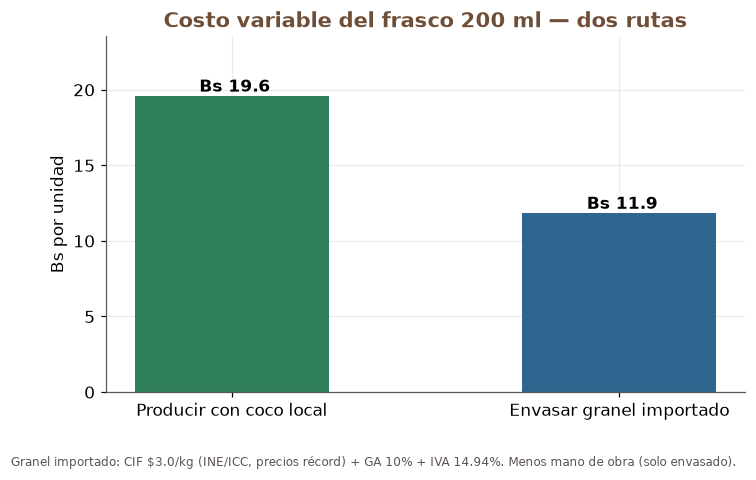

Diferencia: Bs 7.8 por frasco. Con los precios internacionales en máximos
históricos, producir localmente compite — y con precios normales (~$1.500/t) el granel importado
vuelve a ser más barato. La ventaja sostenible del coco local es el RELATO + independencia cambiaria,
no (solo) el costo. Validar el precio real del coco boliviano es la clave.


In [7]:
cif_bs_litro = (P["cif_importado_usd_kg"] * P["densidad_kg_l"] * P["tc_bs_usd"]
                * (1 + P["arancel_ga_pct"]/100) * (1 + P["iva_import_pct"]/100))
cv_importado = (0.2 * cif_bs_litro + P["frasco_200_bs"] + P["etiqueta_bs"]
                + 0.2 * (P["mano_obra_bs_litro"] * 0.5 + P["energia_insumos_bs_litro"] * 0.5))

rutas = pd.Series({
    "Producir con coco local": cv200,
    "Envasar granel importado": cv_importado,
})
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(rutas.index, rutas.values, color=[COCO["verde"], COCO["azul"]], width=0.5)
for x, v in zip(rutas.index, rutas.values):
    ax.text(x, v, f" Bs {v:.1f}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Costo variable del frasco 200 ml — dos rutas")
ax.set_ylabel("Bs por unidad")
ax.set_ylim(0, rutas.max() * 1.2)
plt.figtext(0.01, -0.05, f"Granel importado: CIF ${P['cif_importado_usd_kg']}/kg (INE/ICC, precios récord) + GA {P['arancel_ga_pct']}% + IVA {P['iva_import_pct']}%. Menos mano de obra (solo envasado).",
            fontsize=8, color=COCO["gris"])
guardar("13_rutas")
plt.show()

print(f"Diferencia: Bs {abs(cv200-cv_importado):.1f} por frasco. Con los precios internacionales en máximos")
print("históricos, producir localmente compite — y con precios normales (~$1.500/t) el granel importado")
print("vuelve a ser más barato. La ventaja sostenible del coco local es el RELATO + independencia cambiaria,")
print("no (solo) el costo. Validar el precio real del coco boliviano es la clave.")


## 8. Conclusiones

| Pregunta | Respuesta con los supuestos base (§2) |
|---|---|
| ¿Cuánto cuesta el frasco de 200 ml? | **~Bs 19–20** de costo variable (el coco es ~55 % del costo) |
| ¿Margen a Bs 55? | **~Bs 35 por frasco (~64 %)** — consistente con el nicho premium |
| ¿Punto de equilibrio? | **~200 frascos/mes (~40 L, ~7 por día)** con fijos de ~Bs 7.000/mes |
| ¿Precio competitivo? | Bs 27,5/100 ml te ubica **en la mediana del mercado** (Bs 29), por debajo de Gaia Terra/Viasana y por encima de Copra/Litel |
| ¿Producir vs. envasar importado? | Con precios internacionales récord, **producir compite en costo**; la ventaja durable es el posicionamiento "coco boliviano" |

### Qué validar en campo antes de escalar (en orden de impacto)
1. **Precio real del coco** puesto en planta (Santa Cruz / Chapare / Beni) — domina el costo.
2. **Rendimiento real de TU prensa** (ml/coco) con coco boliviano — segunda variable más sensible.
3. Cotización de **frascos y tapas** al por mayor en Bolivia.
4. **Precio de góndola** de BeCoco en Hipermaxi (no se pudo capturar online).

> Todos los cálculos se recalculan editando la celda §2 y re-ejecutando (`Kernel → Restart & Run All`).
